In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import chi2
#https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.chi2.html

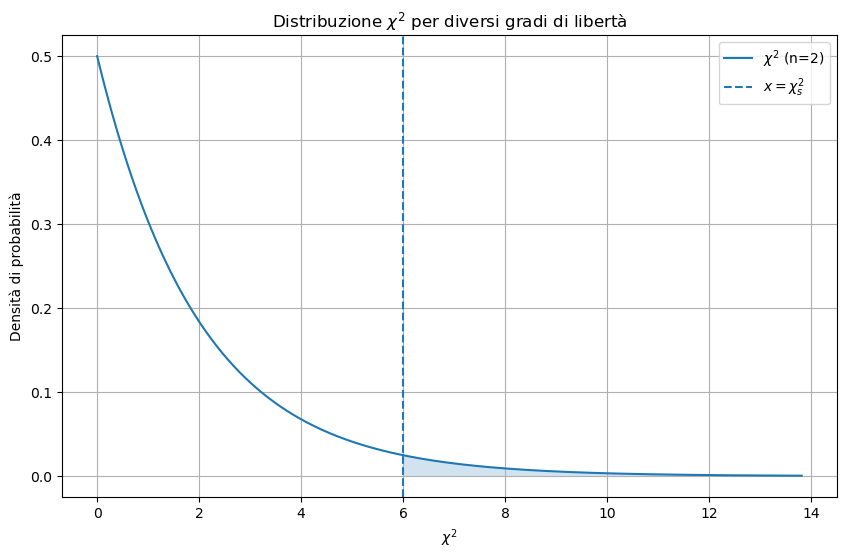

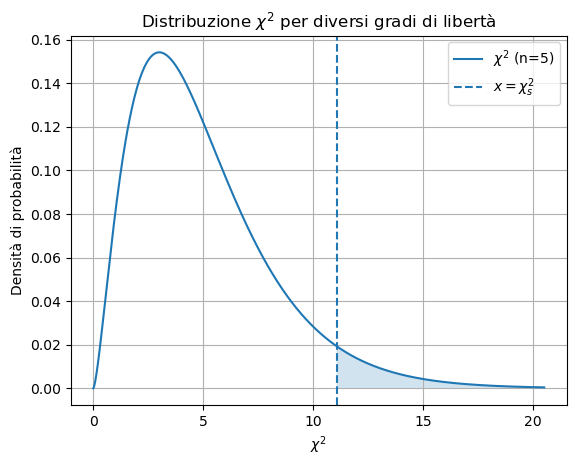

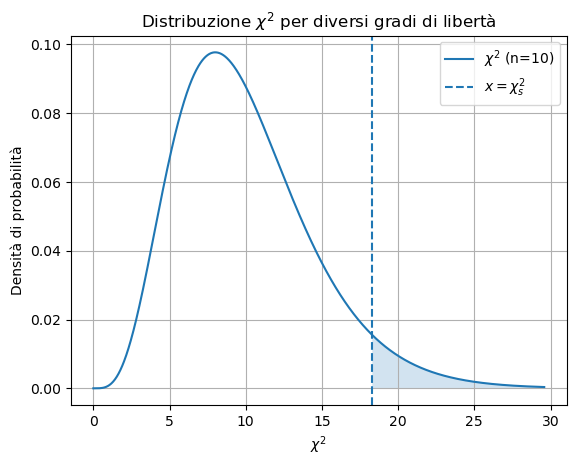

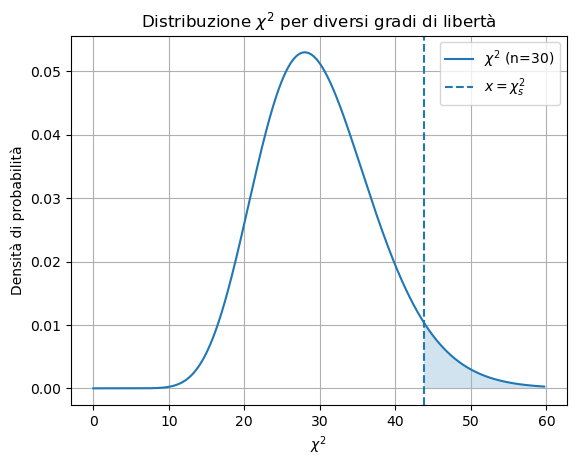

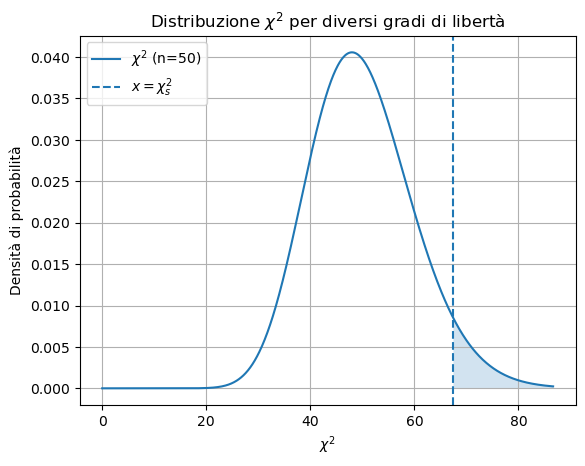

In [2]:
# valori di gradi di libertà
ndf_values = [2, 5, 10, 30, 50]
alpha = 0.05


plt.figure(figsize=(10, 6))

for ndf in ndf_values:

    # asse x adattivo per ogni curva
    x_max = chi2.ppf(0.999, ndf)
    x = np.linspace(0, x_max, 1000)

    y = chi2.pdf(x, df=ndf)
    plt.plot(x, y, label=f'$\chi^2$ (n={ndf})')
    #calcolo la soglia chi2_s per cui Prob(chi2_s)=0.05
    
    chi2_s = chi2.isf(alpha, ndf)
    plt.axvline(x=chi2_s,ls="--", label = "$x = \chi^2_s$")

    # area della coda destra
    x_tail = np.linspace(chi2_s, x_max, 300)
    y_tail = chi2.pdf(x_tail, df=ndf)
    plt.fill_between(x_tail, y_tail, alpha=0.2)

    # grafico
    plt.title('Distribuzione $\chi^2$ per diversi gradi di libertà')
    plt.xlabel('$\chi^2$')
    plt.ylabel('Densità di probabilità')
    plt.legend()
    plt.grid()

    plt.show()

In [3]:
#print di controllo del calcolo del valore di soglia e del pvalue
#suppongo di avere un chi2_m proveniente dal nostro calcolo di 47 con 58 gradi di libertà

chi2_m = 47
ndf = 58

print("Chi2 minimo:",chi2_m)
print("Numero di gradi di libertà",ndf)

alpha = 0.05
chi2_s = chi2.isf(alpha, ndf)
print("Chi quadro di soglia",chi2_s)

if (chi2_m<chi2_s):
    print("Non posso rigettare l'ipotesi!")
else:
    print("Devo rigettare l'ipotesi!")

Chi2 minimo: 47
Numero di gradi di libertà 58
Chi quadro di soglia 76.7778031560615
Non posso rigettare l'ipotesi!


In [4]:
#controllo equivalente con il p-value

p_value = chi2.sf(chi2_m, ndf)
print("p value:",p_value)

if (p_value>alpha):
    print("Non posso rigettare l'ipotesi!")
else:
    print("Devo rigettare l'ipotesi!")

p value: 0.8487647589499604
Non posso rigettare l'ipotesi!


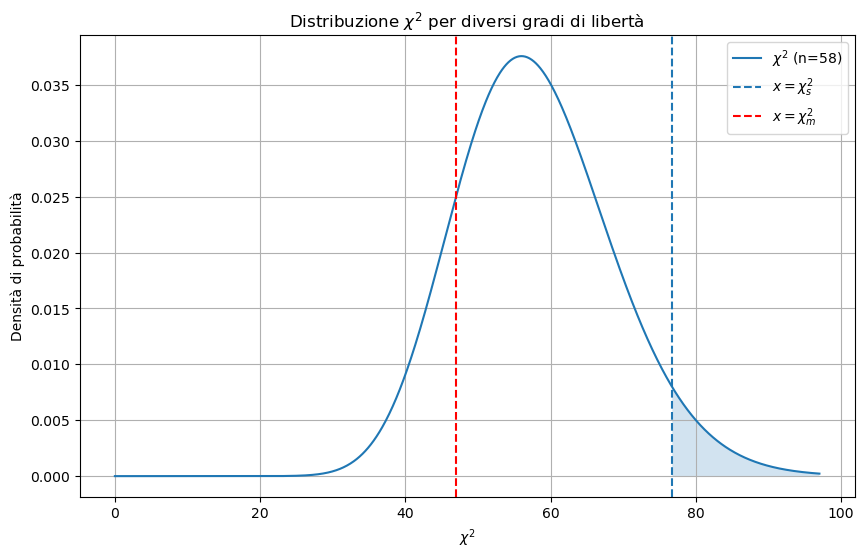

In [5]:
plt.figure(figsize=(10, 6))

x_max = chi2.ppf(0.999, ndf)
x = np.linspace(0, x_max, 1000)

y = chi2.pdf(x, df=ndf)
plt.plot(x, y, label=f'$\chi^2$ (n={ndf})')
    
chi2_s = chi2.isf(alpha, ndf)
plt.axvline(x=chi2_s,ls="--", label = "$x = \chi^2_s$")
plt.axvline(x=chi2_m,ls="--", c="r",label = "$x = \chi^2_m$")
# area della coda destra
x_tail = np.linspace(chi2_s, x_max, 300)
y_tail = chi2.pdf(x_tail, df=ndf)
plt.fill_between(x_tail, y_tail, alpha=0.2)

# grafico
plt.title('Distribuzione $\chi^2$ per diversi gradi di libertà')
plt.xlabel('$\chi^2$')
plt.ylabel('Densità di probabilità')
plt.legend()
plt.grid()

plt.show()